<div style=" background-color: RGB(0,114,200);" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">PROJET 4 DATA ANALYST</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">Réalisez une étude de santé publique avec R ou Python
</h2>
</div>

# OBJECTIF DE CE NOTEBOOK

Bienvenue dans l'outil plébiscité par les analystes de données Jupyter.

Il s'agit d'un outil permettant de mixer et d'alterner codes, textes et graphique.

Cet outil est formidable pour plusieurs raisons:

+ il permet de tester des lignes de codes au fur et à mesure de votre rédaction, de constater immédiatement le résultat d'un instruction, de la corriger si nécessaire.
+ De rédiger du texte pour expliquer l'approche suivie ou les résultats d'une analyse et de le mettre en forme grâce à du code html ou plus simple avec **Markdown**
+ d'agrémenter de graphiques

Pour vous aider dans vos premiers pas à l'usage de Jupyter et de Python, nous avons rédigé ce notebook en vous indiquant les instructions à suivre.

Il vous suffit pour cela de saisir le code Python répondant à l'instruction donnée.

Vous verrez de temps à autre le code Python répondant à une instruction donnée mais cela est fait pour vous aider à comprendre la nature du travail qui vous est demandée.

Et garder à l'esprit, qu'il n'y a pas de solution unique pour résoudre un problème et qu'il y a autant de résolutions de problèmes que de développeurs ;)...



Note jeremy 
Est ce qu'il faut faire le calcul de la sous nutrition sur les pays qu'on a ? 
Est ce qu'il faut faire des graphiques ?
Rajouter le soja
La liste des céréales est difficile a trouver ...

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.1 - Importation des librairies</h3>
</div>

In [2]:
#Importation de la librairie Pandas
import pandas as pd

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">1.2 - Chargement des fichiers Excel</h3>
</div>

In [3]:
#Importation du fichier population.csv
population = pd.read_csv('C:\\Users\\artal\\Desktop\\OpenClassrooms\\Projet 4\\DAN-P4-FAO\\population.csv')

#Importation du fichier dispo_alimentaire.csv
dispo_alimentaire = pd.read_csv('C:\\Users\\artal\\Desktop\\OpenClassrooms\\Projet 4\\DAN-P4-FAO\\dispo_alimentaire.csv')

#Importation du fichier aide_alimentaire.csv
aide_alimentaire = pd.read_csv('C:\\Users\\artal\\Desktop\\OpenClassrooms\\Projet 4\\DAN-P4-FAO\\aide_alimentaire.csv')

#Importation du fichier sous_nutrition.csv
sous_nutrition = pd.read_csv('C:\\Users\\artal\\Desktop\\OpenClassrooms\\Projet 4\\DAN-P4-FAO\\sous_nutrition.csv')

<div style="background-color: RGB(0,150,250);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.1 - Analyse exploratoire du fichier population</h3>
</div>

In [4]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(population.shape[0]))
print("Le tableau comporte {} colonne(s)".format(population.shape[1]))

Le tableau comporte 1416 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [5]:
#Consulter le nombre de colonnes
print(population.shape[1])
#La nature des données dans chacune des colonnes
print(population.dtypes)
#Le nombre de valeurs présentes dans chacune des colonnes
print(population.count())

3
Zone       object
Année       int64
Valeur    float64
dtype: object
Zone      1416
Année     1416
Valeur    1416
dtype: int64


In [6]:
#Affichage les 5 premières lignes de la table
population.head()

,Zone,Année,Valeur
0,Afghanistan,2013,32269.589
1,Afghanistan,2014,33370.794
2,Afghanistan,2015,34413.603
3,Afghanistan,2016,35383.032
4,Afghanistan,2017,36296.113


In [7]:
#Nous allons harmoniser les unités. Pour cela, nous avons décidé de multiplier la population par 1000
#Multiplication de la colonne valeur par 1000
population['Valeur']=population['Valeur']*1000

In [8]:
#changement du nom de la colonne Valeur par Population
population = population.rename(columns={'Valeur':'Population'})

In [9]:
#Affichage les 5 premières lignes de la table pour voir les modifications
population.head()

,Zone,Année,Population
0,Afghanistan,2013,32269589.0
1,Afghanistan,2014,33370794.0
2,Afghanistan,2015,34413603.0
3,Afghanistan,2016,35383032.0
4,Afghanistan,2017,36296113.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.2 - Analyse exploratoire du fichier disponibilité alimentaire</h3>
</div>

In [10]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(dispo_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(dispo_alimentaire.shape[1]))

Le tableau comporte 15605 observation(s) ou article(s)
Le tableau comporte 18 colonne(s)


In [11]:
#Consulter le nombre de colonnes
print(dispo_alimentaire.shape[1])

18


In [12]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,NaN,NaN,5.0,1.72,0.20,0.77,53.0,NaN,NaN,53.0,NaN,53.0,NaN,NaN,NaN
1,Afghanistan,"Agrumes, Autres",vegetale,NaN,NaN,1.0,1.29,0.01,0.02,41.0,2.0,40.0,39.0,2.0,3.0,NaN,NaN,NaN
2,Afghanistan,Aliments pour enfants,vegetale,NaN,NaN,1.0,0.06,0.01,0.03,2.0,NaN,2.0,2.0,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,Ananas,vegetale,NaN,NaN,0.0,0.00,NaN,NaN,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,Bananes,vegetale,NaN,NaN,4.0,2.70,0.02,0.05,82.0,NaN,82.0,82.0,NaN,NaN,NaN,NaN,NaN


In [13]:
#remplacement des NaN dans le dataset par des 0
dispo_alimentaire = dispo_alimentaire.fillna(0)

In [14]:
#multiplication de toutes les lignes contenant des milliers de tonnes en Kg
dispo_alimentaire[['Aliments pour animaux','Autres Utilisations','Disponibilité intérieure','Exportations - Quantité','Importations - Quantité','Nourriture','Pertes','Production',
                   'Semences','Traitement','Variation de stock']]=dispo_alimentaire[['Aliments pour animaux','Autres Utilisations','Disponibilité intérieure','Exportations - Quantité',
                                                                                     'Importations - Quantité','Nourriture','Pertes','Production','Semences','Traitement','Variation de stock']]*1000

In [15]:
#Affichage les 5 premières lignes de la table
dispo_alimentaire.head(5)

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier aide alimentaire</h3>
</div>

In [16]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(aide_alimentaire.shape[0]))
print("Le tableau comporte {} colonne(s)".format(aide_alimentaire.shape[1]))

Le tableau comporte 1475 observation(s) ou article(s)
Le tableau comporte 4 colonne(s)


In [17]:
#Consulter le nombre de colonnes
print(aide_alimentaire.shape[1])

4


In [18]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Pays bénéficiaire,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682
1,Afghanistan,2014,Autres non-céréales,335
2,Afghanistan,2013,Blé et Farin,39224
3,Afghanistan,2014,Blé et Farin,15160
4,Afghanistan,2013,Céréales,40504


In [19]:
#changement du nom de la colonne Pays bénéficiaire par Zone
aide_alimentaire = aide_alimentaire.rename(columns={'Pays bénéficiaire':'Zone'})

In [20]:
#Multiplication de la colonne Aide_alimentaire qui contient des tonnes par 1000 pour avoir des kg
aide_alimentaire['Valeur']=aide_alimentaire['Valeur']*1000

In [21]:
#Affichage les 5 premières lignes de la table
aide_alimentaire.head()

,Zone,Année,Produit,Valeur
0,Afghanistan,2013,Autres non-céréales,682000
1,Afghanistan,2014,Autres non-céréales,335000
2,Afghanistan,2013,Blé et Farin,39224000
3,Afghanistan,2014,Blé et Farin,15160000
4,Afghanistan,2013,Céréales,40504000


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">2.3 - Analyse exploratoire du fichier sous nutrition</h3>
</div>

In [22]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(sous_nutrition.shape[0]))
print("Le tableau comporte {} colonne(s)".format(sous_nutrition.shape[1]))

Le tableau comporte 1218 observation(s) ou article(s)
Le tableau comporte 3 colonne(s)


In [23]:
#Consulter le nombre de colonnes
sous_nutrition.shape[1]

3

In [24]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head()

,Zone,Année,Valeur
0,Afghanistan,2012-2014,8.6
1,Afghanistan,2013-2015,8.8
2,Afghanistan,2014-2016,8.9
3,Afghanistan,2015-2017,9.7
4,Afghanistan,2016-2018,10.5


In [25]:
#Conversion de la colonne sous nutrition en numérique
# sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'])

In [26]:
#Conversion de la colonne (avec l'argument errors=coerce qui permet de convertir automatiquement les lignes qui ne sont pas des nombres en NaN)
#Puis remplacement des NaN en 0
sous_nutrition['Valeur'] = pd.to_numeric(sous_nutrition['Valeur'],errors='coerce').fillna(0)

In [27]:
#changement du nom de la colonne Valeur par sous_nutrition
sous_nutrition=sous_nutrition.rename(columns={'Valeur':'sous_nutrition'})

In [28]:
#Multiplication de la colonne sous_nutrition par 1000000
sous_nutrition['sous_nutrition']=sous_nutrition['sous_nutrition']*1000000

In [29]:
#Afficher les 5 premières lignes de la table
sous_nutrition.head(5)

,Zone,Année,sous_nutrition
0,Afghanistan,2012-2014,8600000.0
1,Afghanistan,2013-2015,8800000.0
2,Afghanistan,2014-2016,8900000.0
3,Afghanistan,2015-2017,9700000.0
4,Afghanistan,2016-2018,10500000.0


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.1 - Proportion de personnes en sous nutrition</h3>
</div>

In [30]:
# Il faut tout d'abord faire une jointure entre la table population et la table sous nutrition, en ciblant l'année 2017
#Conversion de sous_nutrition['Année'] en nombre
sous_nutrition['Année']=sous_nutrition['Année'].str[:4]
sous_nutrition['Année']=pd.to_numeric(sous_nutrition['Année'])+1
#Jointure
data = population.merge(sous_nutrition[sous_nutrition['Année']==2017],how='inner')

In [31]:
#Affichage du dataset
data.head()

,Zone,Année,Population,sous_nutrition
0,Afghanistan,2017,36296113.0,10500000.0
1,Afrique du Sud,2017,57009756.0,3100000.0
2,Albanie,2017,2884169.0,100000.0
3,Algérie,2017,41389189.0,1300000.0
4,Allemagne,2017,82658409.0,0.0


In [32]:
#Calcul et affichage du nombre de personnes en état de sous nutrition
print('Nombre de personnes en état de sous nutrition :',data['sous_nutrition'].sum())
print('Nombre de personnes total :',data['Population'].sum())
print('Pourcentage de personnes en sous nutrition :',round(data['sous_nutrition'].sum()*100/data['Population'].sum(),3))


Nombre de personnes en état de sous nutrition : 535700000.0
Nombre de personnes total : 7543798779.0
Pourcentage de personnes en sous nutrition : 7.101


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.2 - Nombre théorique de personne qui pourrait être nourries</h3>
</div>

In [33]:
#Combien mange en moyenne un être humain ? Source => https://www.vidal.fr/sante/nutrition/equilibre-alimentaire-adulte/recommandations-nutritionnelles-adulte.html
#Pour un homme adulte, l’apport conseillé en énergie est, en moyenne, de 2 400 à 2 600 calories par jour, selon l’activité. Pour une femme adulte, il est de 1 800 à 2 200 calories.
#Moyenne : 2250

In [34]:
#On commence par faire une jointure entre le data frame population et Dispo_alimentaire afin d'ajouter dans ce dernier la population
data2 = dispo_alimentaire.merge(population[population['Année']==2017],how='inner',on='Zone')

In [35]:
#Affichage du nouveau dataframe
data2.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Année,Population
0,Afghanistan,Abats Comestible,animale,0.0,0.0,5.0,1.72,0.20,0.77,53000.0,0.0,0.0,53000.0,0.0,53000.0,0.0,0.0,0.0,2017,36296113.0
1,Afghanistan,"Agrumes, Autres",vegetale,0.0,0.0,1.0,1.29,0.01,0.02,41000.0,2000.0,40000.0,39000.0,2000.0,3000.0,0.0,0.0,0.0,2017,36296113.0
2,Afghanistan,Aliments pour enfants,vegetale,0.0,0.0,1.0,0.06,0.01,0.03,2000.0,0.0,2000.0,2000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0
3,Afghanistan,Ananas,vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0
4,Afghanistan,Bananes,vegetale,0.0,0.0,4.0,2.70,0.02,0.05,82000.0,0.0,82000.0,82000.0,0.0,0.0,0.0,0.0,0.0,2017,36296113.0


In [36]:
#Création de la colonne dispo_kcal avec calcul des kcal disponibles mondialement
data2['dispo_kcal']=data2['Disponibilité alimentaire (Kcal/personne/jour)']*data2['Population']

In [37]:
#Calcul du nombre d'humains pouvant être nourris
round(sum(data2['dispo_kcal']/2250))

9297326501

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.3 - Nombre théorique de personne qui pourrait être nourrie avec les produits végétaux</h3>
</div>

In [38]:
#Transfert des données avec les végétaux dans un nouveau dataframe
data3 = data2[data2['Origine']=='vegetale']

In [39]:
#Calcul du nombre de kcal disponible pour les végétaux
sum(data3['dispo_kcal'])

17260764211501.0

In [40]:
#Calcul du nombre d'humains pouvant être nourris avec les végétaux
round(sum(data3['dispo_kcal'])/2250)

7671450761

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.4 - Utilisation de la disponibilité intérieure</h3>
</div>

In [41]:
#Calcul de la disponibilité totale
sum(dispo_alimentaire['Disponibilité intérieure'])

9848994000.0

In [43]:
#création d'une boucle for pour afficher les différentes valeurs en fonction des colonnes aliments pour animaux, pertes, nourritures, 
res = []
for i in dispo_alimentaire['Produit'].unique():
    dispo = dispo_alimentaire[['Aliments pour animaux','Pertes','Nourriture','Semences','Traitement','Autres Utilisations']][dispo_alimentaire['Produit']==i].sum()
    res.append([i, dispo['Aliments pour animaux'], dispo['Pertes'], dispo['Nourriture'], dispo['Semences'], dispo['Traitement'], dispo['Autres Utilisations']])
res = pd.DataFrame(res,columns=['Produit', 'Aliments pour animaux', 'Pertes', 'Nourriture','Semences','Traitement','Autres Utilisations'])
print(res)

                   Produit  Aliments pour animaux      Pertes   Nourriture  \
0         Abats Comestible              1009000.0     73000.0   15669000.0   
1          Agrumes, Autres                    0.0    810000.0   11359000.0   
2    Aliments pour enfants                    0.0      1000.0     761000.0   
3                   Ananas                    0.0   2745000.0   20757000.0   
4                  Bananes               871000.0  15295000.0   85954000.0   
..                     ...                    ...         ...          ...   
93                  Sorgho             24808000.0   2746000.0   24153000.0   
94        Viande de Suides                    0.0    275000.0  112100000.0   
95     Huile de Son de Riz                    0.0         0.0     845000.0   
96    Sucre non centrifugé               392000.0     27000.0    6777000.0   
97  Viande de Anim Aquatiq                    0.0         0.0          0.0   

    Semences  Traitement  Autres Utilisations  
0        0.0   

([<matplotlib.patches.Wedge at 0x1fa913b80b0>,
 [Text(1.006353736927396, 0.4441307872375724, 'Aliments pour animaux'),
  Text(0.6165439240804542, 0.910973978596247, 'Pertes'),
  Text(-0.9820634969857595, 0.4955313187762216, 'Nourriture'),
  Text(-0.46346765257284456, -0.9975959778480551, 'Semences'),
  Text(0.34281933327279324, -1.045215243255856, 'Traitement'),
  Text(1.0584725261742085, -0.2993925706065362, 'Autres Utilisations')],
 [Text(0.548920220142216, 0.24225315667503944, '13%'),
  Text(0.3362966858620659, 0.49689489741613463, '5%'),
  Text(-0.5356709983558687, 0.2702898102415754, '49%'),
  Text(-0.25280053776700606, -0.5441432606443937, '2%'),
  Text(0.18699236360334173, -0.570117405412285, '22%'),
  Text(0.5773486506404772, -0.1633050385126561, '9%')])

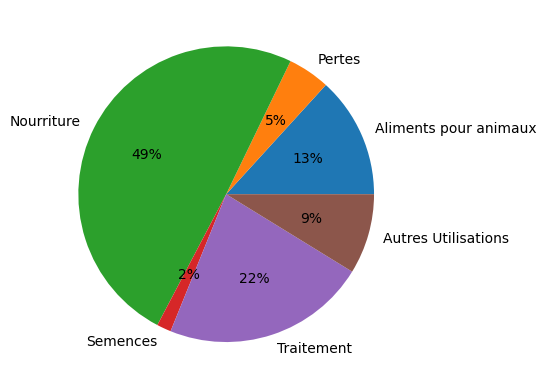

In [45]:
# ajouter un graphique avec la part de chaque catégorie %age
import matplotlib.pyplot as plt
plt.pie(x=[res['Aliments pour animaux'].sum(),res['Pertes'].sum(),res['Nourriture'].sum(),res['Semences'].sum(),res['Traitement'].sum(),res['Autres Utilisations'].sum()],
        labels=['Aliments pour animaux','Pertes','Nourriture','Semences','Traitement','Autres Utilisations'],autopct='%1.0f%%')

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.5 - Utilisation des céréales</h3>
</div>

In [408]:
#Création d'une liste avec toutes les variables
liste_cereales = ['Blé','Riz (Eq Blanchi)','Orge','Maïs','Seigle','Avoine','Millet','Sorgho','Céréales, Autres']

In [409]:
#Création d'un dataframe avec les informations uniquement pour ces céréales
dispo_alimentaire_cereales = dispo_alimentaire[dispo_alimentaire['Produit'].isin(liste_cereales)]
dispo_alimentaire_cereales.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
7,Afghanistan,Blé,vegetale,0.0,0.0,1369.0,160.23,4.69,36.91,5992000.0,0.0,1173000.0,4895000.0,775000.0,5169000.0,322000.0,0.0,-350000.0
12,Afghanistan,"Céréales, Autres",vegetale,0.0,0.0,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32,Afghanistan,Maïs,vegetale,200000.0,0.0,21.0,2.50,0.30,0.56,313000.0,0.0,1000.0,76000.0,31000.0,312000.0,5000.0,0.0,0.0
34,Afghanistan,Millet,vegetale,0.0,0.0,3.0,0.40,0.02,0.08,13000.0,0.0,0.0,12000.0,1000.0,13000.0,0.0,0.0,0.0
40,Afghanistan,Orge,vegetale,360000.0,0.0,26.0,2.92,0.24,0.79,524000.0,0.0,10000.0,89000.0,52000.0,514000.0,22000.0,0.0,0.0


In [410]:
#Affichage de la proportion d'alimentation animale et humaine
# Somme d'aliments pour animaux, nourriture et dispo intérieure pour chaque céréale
res2 = []
for i in dispo_alimentaire_cereales['Produit'].unique():
    dispo = dispo_alimentaire_cereales[['Aliments pour animaux','Nourriture','Disponibilité intérieure']][dispo_alimentaire_cereales['Produit'] == i].sum()
    res2.append([i, dispo['Aliments pour animaux'],dispo['Nourriture'],dispo['Disponibilité intérieure']])
res2 = pd.DataFrame(res2,columns=['Produit', 'Aliments pour animaux','Nourriture','Disponibilité intérieure'])
# Ajout de la proportion d'alimentation animale et humaine
res2['Proportion animale']=res2['Aliments pour animaux']/res2['Disponibilité intérieure']
res2['Proportion humaine']=res2['Nourriture']/res2['Disponibilité intérieure']
print(res2)


            Produit  Aliments pour animaux   Nourriture  \
0               Blé            129668000.0  457824000.0   
1  Céréales, Autres             19035000.0    5324000.0   
2              Maïs            546116000.0  125184000.0   
3            Millet              3306000.0   23040000.0   
4              Orge             92658000.0    6794000.0   
5  Riz (Eq Blanchi)             33594000.0  377286000.0   
6            Avoine             16251000.0    3903000.0   
7            Seigle              8099000.0    5502000.0   
8            Sorgho             24808000.0   24153000.0   

   Disponibilité intérieure  Proportion animale  Proportion humaine  
0               679498000.0            0.190829            0.673768  
1                27485000.0            0.692560            0.193706  
2               955799000.0            0.571371            0.130973  
3                29911000.0            0.110528            0.770285  
4               140439000.0            0.659774            

Text(0.5, 1.0, 'Part de l’utilisation des principales céréales \nentre l’alimentation humaine et animale')

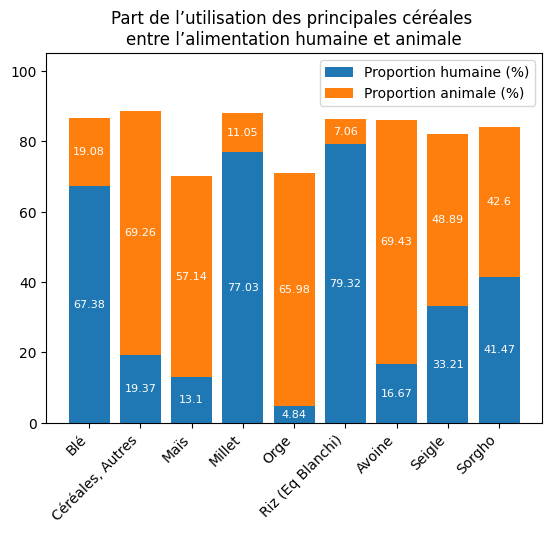

In [411]:
#Graphique
bar1 = plt.bar(res2['Produit'], res2['Proportion humaine'].round(4)*100, label='Proportion humaine (%)')
bar2 = plt.bar(res2['Produit'], res2['Proportion animale'].round(4)*100, bottom=res2['Proportion humaine'].round(4)*100, label='Proportion animale (%)')
plt.ylim(0,105)
plt.xticks(rotation=45,ha='right')
plt.bar_label(bar1, label_type='center', color='white', fontsize=8)
plt.bar_label(bar2, label_type='center', color='white', fontsize=8)
plt.legend()
plt.title('Part de l’utilisation des principales céréales \nentre l’alimentation humaine et animale')



<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.6 - Pays avec la proportion de personnes sous-alimentée la plus forte en 2017</h3>
</div>

In [412]:
#Création de la colonne proportion par pays
data['Proportion par pays']=data['sous_nutrition']/data['Population']
data.head()

,Zone,Année,Population,sous_nutrition,Proportion par pays
0,Afghanistan,2017,36296113.0,10500000.0,0.289287
1,Afrique du Sud,2017,57009756.0,3100000.0,0.054377
2,Albanie,2017,2884169.0,100000.0,0.034672
3,Algérie,2017,41389189.0,1300000.0,0.031409
4,Allemagne,2017,82658409.0,0.0,0.000000


In [413]:
#affichage après trie des 10 pires pays
data.sort_values(by='Proportion par pays',ascending=False).head(10)

,Zone,Année,Population,sous_nutrition,Proportion par pays
78,Haïti,2017,10982366.0,5300000.0,0.482592
157,République populaire démocratique de Corée,2017,25429825.0,12000000.0,0.471887
108,Madagascar,2017,25570512.0,10500000.0,0.410629
103,Libéria,2017,4702226.0,1800000.0,0.382797
100,Lesotho,2017,2091534.0,800000.0,0.382494
183,Tchad,2017,15016753.0,5700000.0,0.379576
161,Rwanda,2017,11980961.0,4200000.0,0.350556
121,Mozambique,2017,28649018.0,9400000.0,0.328109
186,Timor-Leste,2017,1243258.0,400000.0,0.321735
0,Afghanistan,2017,36296113.0,10500000.0,0.289287


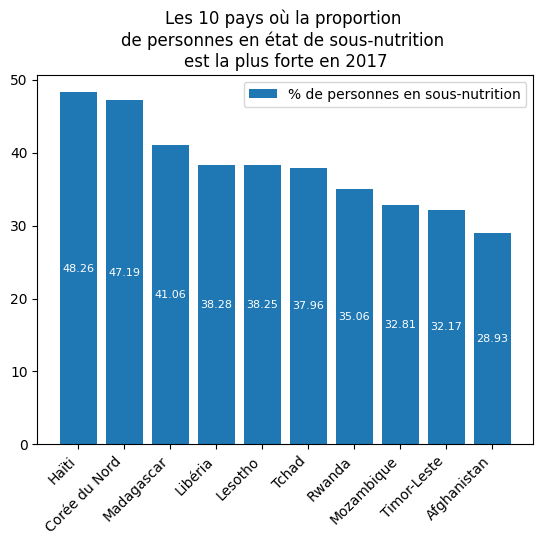

In [452]:
data2 = data.sort_values(by='Proportion par pays',ascending=False).head(10)
data2.iloc[1,0]='Corée du Nord'
bar = plt.bar(data2['Zone'],data2['Proportion par pays'].round(4)*100,label='% de personnes en sous-nutrition')
plt.xticks(rotation=45,ha='right')
plt.bar_label(bar, label_type='center', color='white', fontsize=8)
plt.title('Les 10 pays où la proportion \nde personnes en état de sous-nutrition \nest la plus forte en 2017')
plt.legend()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.7 - Pays qui ont le plus bénéficié d'aide alimentaire depuis 2013</h3>
</div>

In [415]:
#calcul du total de l'aide alimentaire par pays
total = aide_alimentaire.groupby('Zone')['Valeur'].sum().reset_index().sort_values('Valeur',ascending=False)

In [416]:
#affichage après trie des 10 pays qui ont bénéficié le plus de l'aide alimentaire
total.head(10)

,Zone,Valeur
50,République arabe syrienne,1858943000
75,Éthiopie,1381294000
70,Yémen,1206484000
61,Soudan du Sud,695248000
60,Soudan,669784000
30,Kenya,552836000
3,Bangladesh,348188000
59,Somalie,292678000
53,République démocratique du Congo,288502000
43,Niger,276344000


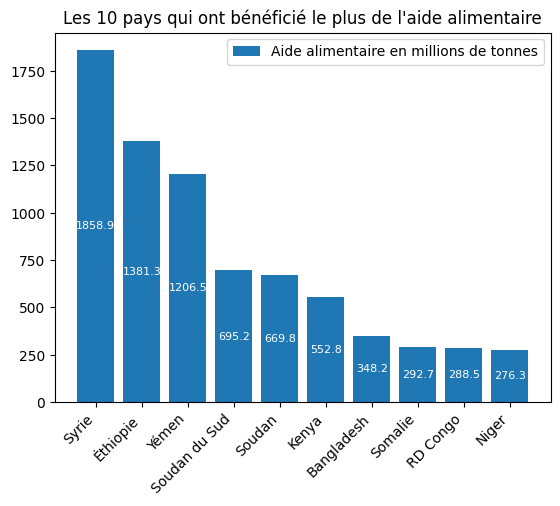

In [417]:
total2 = total.head(10)
total2.iloc[0,0]='Syrie'
total2.iloc[8,0]='RD Congo'
bar = plt.bar(total2['Zone'],(total2['Valeur']/1000000).round(1),label='Aide alimentaire en millions de tonnes')
plt.xticks(rotation=45,ha='right')
plt.bar_label(bar, label_type='center', color='white', fontsize=8)
plt.title("Les 10 pays qui ont bénéficié le plus de l'aide alimentaire")
plt.legend()

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.8 - Evolution des 5 pays qui ont le plus bénéficiés de l'aide alimentaire entre 2013 et 2016</h3>
</div>

In [418]:
#Création d'un dataframe avec la zone, l'année et l'aide alimentaire puis groupby sur zone et année 
evo = aide_alimentaire[['Zone','Année','Valeur']]
evo = evo.groupby(['Zone','Année'])['Valeur'].sum().reset_index()

In [419]:
#Création d'une liste contenant les 5 pays qui ont le plus bénéficiées de l'aide alimentaire
top5 = evo.groupby('Zone')['Valeur'].sum().reset_index().sort_values('Valeur',ascending=False)['Zone'].head().to_list()
top5

['République arabe syrienne', 'Éthiopie', 'Yémen', 'Soudan du Sud', 'Soudan']

In [420]:
#On filtre sur le dataframe avec notre liste
evoTop5 = evo[evo['Zone'].isin(top5)]
evoTop5

,Zone,Année,Valeur
157,République arabe syrienne,2013,563566000
158,République arabe syrienne,2014,651870000
159,République arabe syrienne,2015,524949000
160,République arabe syrienne,2016,118558000
189,Soudan,2013,330230000
190,Soudan,2014,321904000
191,Soudan,2015,17650000
192,Soudan du Sud,2013,196330000
193,Soudan du Sud,2014,450610000
194,Soudan du Sud,2015,48308000


Text(0.5, 1.0, 'Évolution de l’aide alimentaire pour les 5 pays \nqui en ont le plus bénéficié entre 2013 et 2016')

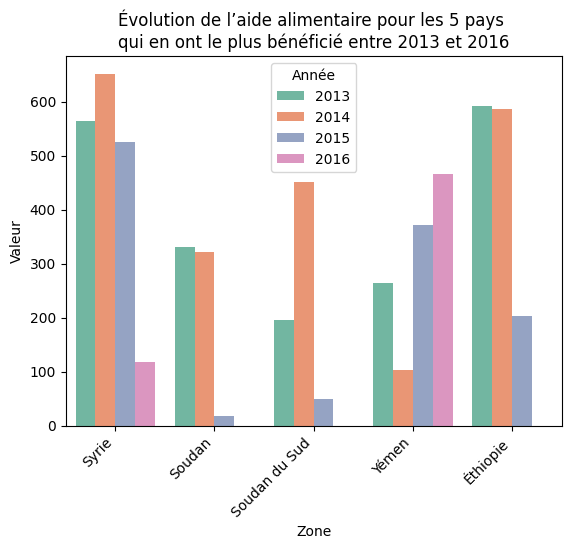

In [453]:
# Affichage des pays avec l'aide alimentaire par année
import seaborn as sns
evoTop5.iloc[0:4,0]="Syrie"
sns.barplot(data=evoTop5,x='Zone',y=evoTop5['Valeur']/1000000,errorbar=None,hue='Année',palette='Set2')
plt.xticks(rotation=45,ha='right')
plt.title('Évolution de l’aide alimentaire pour les 5 pays \nqui en ont le plus bénéficié entre 2013 et 2016')


<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.9 - Pays avec le moins de disponibilité par habitant</h3>
</div>

In [422]:
#Calcul de la disponibilité en kcal par personne par jour par pays
dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index().sort_values('Disponibilité alimentaire (Kcal/personne/jour)').head(10)

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
128,République centrafricaine,1879.0
166,Zambie,1924.0
91,Madagascar,2056.0
0,Afghanistan,2087.0
65,Haïti,2089.0
133,République populaire démocratique de Corée,2093.0
151,Tchad,2109.0
167,Zimbabwe,2113.0
114,Ouganda,2126.0
172,Éthiopie,2129.0


In [423]:
#Affichage des 10 pays qui ont le moins de dispo alimentaire par personne 
top10 = dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index().sort_values('Disponibilité alimentaire (Kcal/personne/jour)').head(10)

Text(0.5, 1.0, 'Les 10 pays qui ont le moins de dispo alimentaire par personne \n(Kcal/personne/jour)')

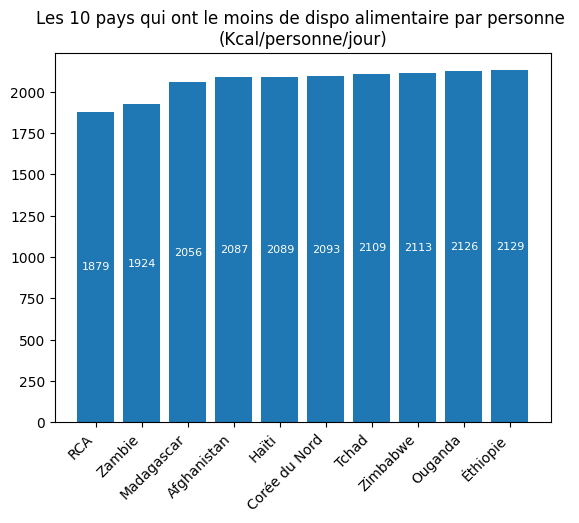

In [424]:
top10.iloc[5,0]='Corée du Nord'
top10.iloc[0,0]='RCA'
bar = plt.bar(top10['Zone'],top10['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.xticks(rotation=45,ha='right')
plt.bar_label(bar, label_type='center', color='white', fontsize=8)
plt.title("Les 10 pays qui ont le moins de dispo alimentaire par personne \n(Kcal/personne/jour)")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.10 - Pays avec le plus de disponibilité par habitant</h3>
</div>

In [425]:
#Affichage des 10 pays qui ont le plus de dispo alimentaire par personne 
top10_2 = dispo_alimentaire.groupby('Zone')['Disponibilité alimentaire (Kcal/personne/jour)'].sum().reset_index().sort_values('Disponibilité alimentaire (Kcal/personne/jour)',ascending=False).head(10)
top10_2

,Zone,Disponibilité alimentaire (Kcal/personne/jour)
11,Autriche,3770.0
16,Belgique,3737.0
159,Turquie,3708.0
171,États-Unis d'Amérique,3682.0
74,Israël,3610.0
72,Irlande,3602.0
75,Italie,3578.0
89,Luxembourg,3540.0
168,Égypte,3518.0
4,Allemagne,3503.0


Text(0.5, 1.0, "Les 10 pays 'qui ont le plus de dispo alimentaire par personne \n(Kcal/personne/jour)")

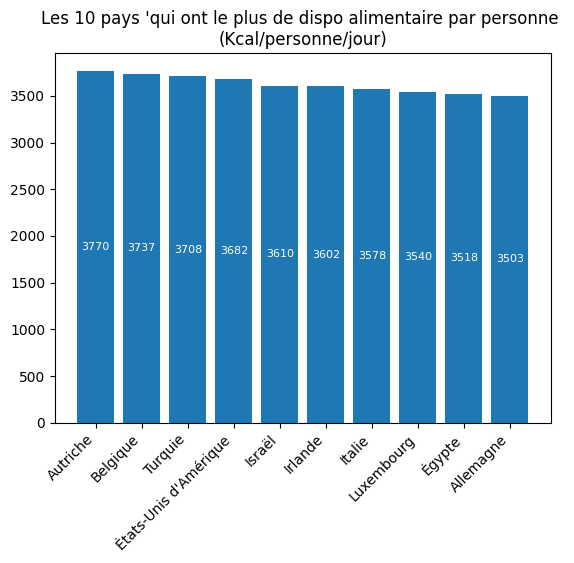

In [455]:
bar = plt.bar(top10_2['Zone'],top10_2['Disponibilité alimentaire (Kcal/personne/jour)'])
plt.xticks(rotation=45,ha='right')
plt.bar_label(bar, label_type='center', color='white', fontsize=8)
plt.title("Les 10 pays qui ont le plus de dispo alimentaire par personne \n(Kcal/personne/jour)")

<div style="border: 1px solid RGB(0,150,250);" >
<h3 style="margin: auto; padding: 20px; color: RGB(0,150,250); ">3.11 - Exemple de la Thaïlande pour le Manioc</h3>
</div>

In [427]:
#création d'un dataframe avec uniquement la Thaïlande 
thailande = dispo_alimentaire[dispo_alimentaire['Zone']=='Thaïlande']
thailande.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock
13759,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000.0,5000.0,33000.0,75000.0,0.0,45000.0,0.0,0.0,0.0
13760,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000.0,6000.0,2000.0,6000.0,0.0,12000.0,0.0,2000.0,0.0
13761,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000.0,0.0,0.00,0.00,0.00,358000.0,110000.0,21000.0,0.0,0.0,447000.0,0.0,0.0,0.0
13762,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000.0,7000.0,19000.0,12000.0,0.0,0.0,0.0,0.0,0.0
13763,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000.0,1449000.0,9000.0,671000.0,110000.0,2209000.0,0.0,0.0,13000.0


In [434]:
#Calcul de la sous nutrition en Thaïlande
sous_nutrition_thailande = sous_nutrition[sous_nutrition['Zone']=='Thaïlande'].merge(population[population['Zone']=='Thaïlande'],how='inner',on=['Zone','Année'])
sous_nutrition_thailande.loc[:,'Proportion sous nutrition']=(sous_nutrition_thailande['sous_nutrition']*100/sous_nutrition_thailande['Population']).round(2)
sous_nutrition_thailande

,Zone,Année,sous_nutrition,Population,Proportion sous nutrition
0,Thaïlande,2013,6200000.0,68144518.0,9.10
1,Thaïlande,2014,6000000.0,68438746.0,8.77
2,Thaïlande,2015,5900000.0,68714511.0,8.59
3,Thaïlande,2016,6000000.0,68971308.0,8.70
4,Thaïlande,2017,6200000.0,69209810.0,8.96
5,Thaïlande,2018,6500000.0,69428453.0,9.36


In [437]:
# On calcule la proportion exportée en fonction de la proportion
thailande.loc[:,'Proportion exportée']=thailande['Exportations - Quantité']/thailande['Disponibilité intérieure']
thailande.head()

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Proportion exportée
13759,Thaïlande,Abats Comestible,animale,0.0,0.0,3.0,1.11,0.09,0.56,74000.0,5000.0,33000.0,75000.0,0.0,45000.0,0.0,0.0,0.0,0.067568
13760,Thaïlande,"Agrumes, Autres",vegetale,0.0,0.0,0.0,0.09,0.00,0.00,8000.0,6000.0,2000.0,6000.0,0.0,12000.0,0.0,2000.0,0.0,0.750000
13761,Thaïlande,"Alcool, non Comestible",vegetale,0.0,358000.0,0.0,0.00,0.00,0.00,358000.0,110000.0,21000.0,0.0,0.0,447000.0,0.0,0.0,0.0,0.307263
13762,Thaïlande,Aliments pour enfants,vegetale,0.0,0.0,2.0,0.18,0.01,0.08,12000.0,7000.0,19000.0,12000.0,0.0,0.0,0.0,0.0,0.0,0.583333
13763,Thaïlande,Ananas,vegetale,0.0,0.0,10.0,10.02,0.04,0.08,782000.0,1449000.0,9000.0,671000.0,110000.0,2209000.0,0.0,0.0,13000.0,1.852941


In [450]:
thailande[thailande['Produit']=='Manioc']
#quasiment tout est exporté
#source de revenus fiable pour beaucoup d'agriculteurs thailandais

,Zone,Produit,Origine,Aliments pour animaux,Autres Utilisations,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Semences,Traitement,Variation de stock,Proportion exportée
13809,Thaïlande,Manioc,vegetale,1800000.0,2081000.0,40.0,13.0,0.05,0.14,6264000.0,25214000.0,1250000.0,871000.0,1511000.0,30228000.0,0.0,0.0,0.0,4.025223
